07 · Street geometry (lengths, bearings, speeds, circuity)

Notebook 06 gets a clean street network into Blender. This one measures its
shape. The four measurements differ in trustworthiness: a length is a
geodetic fact, a bearing is a *circular* one, about a third of the speeds are
imputed with nothing to mark them, and circuity inherits whatever the length
got wrong.

Every number is planar; notebook 11 covers elevation and grades, which is why
no figure here sits on terrain or under buildings.

Three street networks, tens of kilobytes of Overpass each, cached after the
first run.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import ast
import importlib
import math
import shutil
from collections import Counter

import bpy
import numpy as np
import pandas as pd

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

# Before anything asks Overpass for a byte: the add-on sets `use_cache` but not
# `cache_folder`, so the default resolves against Blender's working directory
# and a run started elsewhere re-downloads everything.
ox = nb.osmnx()

# Operators keep their graphs in the installed add-on's module-level cache, and
# `import SciGraphs` from this tree is a different module object with a
# different, empty one (notebook 11 section 9).
INSTALLED = next(k for k in bpy.context.preferences.addons.keys()
                 if k.rsplit(".", 1)[-1].lower() == "scigraphs")
graph_cache = importlib.import_module(INSTALLED + ".core.osmnx.graph_cache")
# `scigraphs_core` is a wheel: one copy in site-packages, shared by the notebook
# and the operators, so the installed/working-tree split does not apply to it.
mesh_bridge = importlib.import_module("scigraphs_core.osmnx.mesh_bridge")
sg_bearing = importlib.import_module("scigraphs_core.osmnx.bearing")

props = bpy.context.scene.scigraphs

print("osmnx", ox.__version__)
print("cache", nb.rel(ox.settings.cache_folder))

osmnx 2.0.7
cache notebooks/data/cache/osmnx


### The three study areas

All at 600 m radius on the `drive` network. Same country, same decade of OSM
coverage, same filter.

| Place | Why |
|---|---|
| Ciutat Vella, València | Medieval core with a nineteenth-century grid grafted onto its southern edge. The mixed case. |
| L'Eixample, València | The 1884 *ensanche* to the south. A rigid orthogonal grid, rotated off north. |
| Albaicín, Granada | Grew on a hillside rather than being laid out. The organic case, and the network notebook 11 climbs. |

In [2]:
PLACES = {
    "Ciutat Vella": dict(lat=39.4699, lon=-0.3763, dist=600,
                         name="Streets_CiutatVella"),
    "Eixample": dict(lat=39.4640, lon=-0.3700, dist=600,
                     name="Streets_Eixample"),
    "Albaicin": dict(lat=37.1800, lon=-3.5920, dist=600,
                     name="Streets_Albaicin"),
}

RENDERS = "07_osmnx_geometry"


def import_network(lat, lon, dist, name, network_type='drive'):
    """One `import_osm_graph` call, and the object it produced.

    The operator does not return the object, so this diffs the object list. It
    also renames the result: every import arrives called
    `OSMnx_StreetNetwork`, and section 3 has an operator that writes a file
    named after the object.
    """
    scene_props = bpy.context.scene.scigraphs
    scene_props.osmnx_download_method = 'POINT'
    scene_props.osmnx_latitude, scene_props.osmnx_longitude = lat, lon
    scene_props.osmnx_distance = dist
    scene_props.osmnx_network_type = network_type
    scene_props.osmnx_simplify = True

    before = {o.name for o in bpy.data.objects}
    result = bpy.ops.scigraphs.import_osm_graph()
    fresh = [o for o in bpy.data.objects
             if o.name not in before and o.get("is_osmnx")]
    if not fresh:
        raise RuntimeError(f"import_osm_graph returned {result} and no object")
    obj = fresh[-1]
    obj.name = name
    return obj


sg.graphs.clear_scene(keep_anchor=False)

nets = {label: import_network(**spec) for label, spec in PLACES.items()}

for label, obj in nets.items():
    print(f"{label:<14} {obj['num_nodes']:>4} intersections  "
          f"{obj['num_edges']:>4} segments  "
          f"{obj['total_length_m'] / 1000:>5.1f} km  "
          f"mesh {len(obj.data.vertices):>5} verts / {len(obj.data.edges):>5} edges")

check("three networks are in the scene", len(nets) == 3)


  retain_all: True (disconnected components kept)
  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 0.29s
Total import time: 0.32s
  Nodes: 246, Edges: 377

Creating OSMnx graph: 246 nodes, 377 edges...
  Created 246 intersection vertices
  Created 363 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_drive.graphml
Info: Imported: 246 intersections, 377 street segments, 32.6 km total

  retain_all: True (disconnected components kept)
  Point: (39.4640007019043, -0.3700000047683716), radius: 600m
  Download completed in 0.49s
Total import time: 0.52s
  Nodes: 276, Edges: 443

Creating OSMnx graph: 276 nodes, 443 edges...
  Created 276 in

True

> The coordinates that went over the wire are not the literals
> above. `props.osmnx_latitude` is a single-precision `FloatProperty`, so
> `39.4699` becomes `39.46989822387695`, and OSMnx keys its disk cache on the
> query string built from that. A cache warmed by calling OSMnx directly with
> the literal misses every time the operator asks. Notebook 11 section 2
> derives it.

The mesh is not the graph: 243 intersections arrive as 1374
vertices, because `create_osmnx_graph_mesh` also stores every shape point of
every centerline.

`sg.preview.extent()` reads `obj["node_positions"]`, which that importer does not
write (`SciGraphs/core/mesh/geometry.py:1750`), and falls back to *all* mesh
vertices. It then measures the centerline sampling step, a few meters,
instead of the distance between junctions, so every node radius derived from
it comes out about 3.8x too small. `sg.render.node_cloud()` reads the
`is_intersection` vertex layer the importer does write. Every figure below
goes through it, so this is checked once and then trusted.

In [3]:
for label, obj in nets.items():
    cloud, source = sg.render.node_cloud(obj)
    (_center, _size, _diagonal, median_nn), _src = sg.render.measure(obj)
    print(f"{label:<14} node cloud {len(cloud):>4} of {len(obj.data.vertices):>5} "
          f"vertices via '{source}'   median nearest neighbor {median_nn:.5f} BU")
    check(f"{label}: the node cloud is the junctions, not the shape points",
          source == "is_intersection" and len(cloud) == obj["num_nodes"])

Ciutat Vella   node cloud  246 of  1443 vertices via 'is_intersection'   median nearest neighbor 0.03503 BU
[PASS] Ciutat Vella: the node cloud is the junctions, not the shape points
Eixample       node cloud  276 of  1176 vertices via 'is_intersection'   median nearest neighbor 0.02463 BU
[PASS] Eixample: the node cloud is the junctions, not the shape points
Albaicin       node cloud  221 of  1415 vertices via 'is_intersection'   median nearest neighbor 0.02897 BU
[PASS] Albaicin: the node cloud is the junctions, not the shape points


## 1 · Length: what the network already knows

OSMnx computes each edge's `length` in meters at download time, in
`osmnx.distance.add_edge_lengths`, as the great-circle distance on a sphere
of radius 6 371 009 m between consecutive nodes of the *unsimplified* graph.
Simplification sums the pieces, which is why a simplified edge's `length`
follows the bend of the street instead of cutting across it.

In [4]:
vlc = nets["Ciutat Vella"]
sg.graphs.activate(vlc)
G = graph_cache.get_osmnx_graph(vlc)

print("graph:", type(G).__name__, G.number_of_nodes(), "nodes,",
      G.number_of_edges(), "edges, crs", G.graph.get("crs"))
print("edge attributes:", sorted(next(iter(G.edges(data=True)))[2].keys()))

lengths = np.array([d["length"] for *_e, d in G.edges(data=True)], float)
print("\nsegment length, meters:")
for q in (5, 25, 50, 75, 90, 95, 98, 100):
    print(f"  p{q:<3} {np.percentile(lengths, q):>7.1f}")
print(f"  total {lengths.sum() / 1000:.2f} km "
      f"(the object says {vlc['total_length_m'] / 1000:.2f} km)")

check("the graph is unprojected",
      not ox.projection.is_projected(G.graph["crs"]),
      "which is what makes bearings computable, and what breaks "
      "osmnx_add_edge_lengths, section 7")

graph: MultiDiGraph 246 nodes, 377 edges, crs epsg:4326
edge attributes: ['geometry', 'highway', 'lanes', 'length', 'maxspeed', 'name', 'oneway', 'osmid', 'reversed']

segment length, meters:
  p5      14.5
  p25     38.6
  p50     75.1
  p75    111.8
  p90    154.6
  p95    189.2
  p98    240.1
  p100   587.6
  total 32.58 km (the object says 32.58 km)
[PASS] the graph is unprojected — which is what makes bearings computable, and what breaks osmnx_add_edge_lengths, section 7


True

### Great circle against euclidean, measured

`scigraphs.osmnx_calc_great_circle` and `scigraphs.osmnx_calc_euclidean` sit
side by side on one pair of coordinate fields, with nothing to say they
belong to different coordinate systems. Three distances between the same
endpoint pairs:

- great circle: OSMnx's own, on a sphere of 6 371 009 m, the one `length` is
  made of;
- geodesic: on the WGS84 ellipsoid, via `pyproj.Geod`, the reference;
- planar: straight-line in UTM zone 30N after projecting.

In [5]:
from pyproj import Geod, Transformer

uv = [(u, v) for u, v, _k in G.edges(keys=True)]
y1 = np.array([G.nodes[u]["y"] for u, _v in uv])
x1 = np.array([G.nodes[u]["x"] for u, _v in uv])
y2 = np.array([G.nodes[v]["y"] for _u, v in uv])
x2 = np.array([G.nodes[v]["x"] for _u, v in uv])

great_circle = ox.distance.great_circle(y1, x1, y2, x2)
_az1, _az2, geodesic = Geod(ellps="WGS84").inv(x1, y1, x2, y2)
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32630", always_xy=True)
X1, Y1 = to_utm.transform(x1, y1)
X2, Y2 = to_utm.transform(x2, y2)
planar = np.hypot(X2 - X1, Y2 - Y1)

print(f"{'':<24}{'total (m)':>12}{'vs geodesic':>14}")
for name, values in (("great circle (sphere)", great_circle),
                     ("geodesic (WGS84)", geodesic),
                     ("planar (UTM 30N)", planar)):
    print(f"{name:<24}{values.sum():>12.1f}"
          f"{100 * (values.sum() / geodesic.sum() - 1):>13.4f}%")

planar_error = np.abs(planar - geodesic) / geodesic
sphere_error = np.abs(great_circle - geodesic) / geodesic
print("\nper edge, relative to the geodesic:")
print(f"  planar  median {np.median(planar_error):.3e}   max {planar_error.max():.3e}")
print(f"  sphere  median {np.median(sphere_error):.3e}   max {sphere_error.max():.3e}")

                           total (m)   vs geodesic
great circle (sphere)        31043.7      -0.0381%
geodesic (WGS84)             31055.5       0.0000%
planar (UTM 30N)             31062.6       0.0227%

per edge, relative to the geodesic:
  planar  median 2.272e-04   max 2.308e-04
  sphere  median 1.506e-03   max 2.470e-03


The projection is the accurate one. At 39.47 °N, on segments of
tens to hundreds of meters, UTM 30N plus Pythagoras is off by a median
2.3 × 10⁻⁴, near-constant across every edge because it is not measurement
error but the zone's scale factor: València sits 2.6° east of UTM 30N's
central meridian, where `pyproj` reports a local scale of 1.000227 in both
directions.

The sphere is worse by about a factor of seven. `great_circle` uses a
mean-radius sphere, a poorer model of the ellipsoid at this latitude than a
correctly chosen transverse Mercator zone: a *systematic* 0.03 % shortfall on
the network total, about 7 m over 22 km.

Neither matters for the lengths used here; both do when an OSMnx `length`
disagrees in the fourth digit with a GIS measurement in a projected CRS.

In [6]:
check("planar and spherical distance agree to better than 0.1 %",
      abs(planar.sum() / great_circle.sum() - 1) < 1e-3,
      f"{100 * (planar.sum() / great_circle.sum() - 1):.4f} % over "
      f"{geodesic.sum() / 1000:.1f} km")

[PASS] planar and spherical distance agree to better than 0.1 % — 0.0609 % over 31.1 km


True

### The two operators, on one pair of points

`osmnx_calc_great_circle` reads `osmnx_dist_y1/x1/y2/x2` as latitude and
longitude and reports meters. `osmnx_calc_euclidean` reads the same four
fields and reports `hypot` in whatever units they are in, which for degrees
is degrees. The panel labels the result "units"; nothing stops you.

In [7]:
props.osmnx_dist_y1, props.osmnx_dist_x1 = 39.4699, -0.3763
props.osmnx_dist_y2, props.osmnx_dist_x2 = 39.4750, -0.3700

bpy.ops.scigraphs.osmnx_calc_euclidean()
euclidean_result = props.osmnx_distance_result
bpy.ops.scigraphs.osmnx_calc_great_circle()
great_circle_result = props.osmnx_distance_result

print(f"osmnx_calc_euclidean    {euclidean_result:>12.6f}   'units' (degrees)")
print(f"osmnx_calc_great_circle {great_circle_result:>12.2f}   meters")
print(f"ratio                   {great_circle_result / euclidean_result:>12.0f}   "
      f"meters per degree along this heading")

check("the euclidean operator returns degrees for lat/lon input",
      euclidean_result < 1.0,
      "it is for projected coordinates; feed it lat/lon and the answer is "
      "dimensionally wrong rather than merely imprecise")

Info: Euclidean distance: 0.01 units
Info: Great circle distance: 0.784 km (783.6 m)
osmnx_calc_euclidean        0.008106   'units' (degrees)
osmnx_calc_great_circle       783.61   meters
ratio                          96674   meters per degree along this heading
[PASS] the euclidean operator returns degrees for lat/lon input — it is for projected coordinates; feed it lat/lon and the answer is dimensionally wrong rather than merely imprecise


True

### The length figure

`length` lives on the graph, not the mesh, so
`transfer_edge_attribute_to_mesh` carries it across.

In [8]:
writes = mesh_bridge.transfer_edge_attribute_to_mesh(vlc, G, "length", "edge_length_m")
mesh_lengths = np.zeros(len(vlc.data.edges))
vlc.data.attributes["edge_length_m"].data.foreach_get("value", mesh_lengths)

print(f"graph edges {G.number_of_edges()},  mesh edges {len(vlc.data.edges)},  "
      f"{len(vlc.data.edges) / G.number_of_edges():.2f} mesh edges per street")
print(f"attribute writes reported: {writes}")
print(f"length   graph: mean {lengths.mean():>6.1f}  median {np.median(lengths):>6.1f}  "
      f"p98 {np.percentile(lengths, 98):>6.1f}")
print(f"         mesh : mean {mesh_lengths.mean():>6.1f}  median {np.median(mesh_lengths):>6.1f}  "
      f"p98 {np.percentile(mesh_lengths, 98):>6.1f}")

graph edges 377,  mesh edges 1560,  4.14 mesh edges per street
attribute writes reported: 1633
length   graph: mean   86.4  median   75.1  p98  240.1
         mesh : mean  134.2  median  102.2  p98  572.3


The mesh copy is the same quantity sampled differently, not a
corrupted one. Every mesh edge along a street carries that street's whole
length, so a curved boulevard with forty shape points contributes forty
samples and a short alley one. Mesh statistics are shape-point weighted, and
the mean comes out about 46 % above the graph's.

That is the distribution the color ramp clips against: `clip_high_pct=98`
lands on 566 m rather than the graph's 235 m, so the ramp is spent on a
handful of long roads and the medieval core stays in the bottom stop.
Clipping lower (90 → 211 m) spends the scale on the streets the figure is
about.

Every figure here is top-down orthographic, `render_eevee`'s default, because
a length measured off a tilted map is not a length, and uses `look='ink'`:
the blackest of the five backdrops, with a turbo ramp running dark blue to
red without passing near it.

edge_length_m domain: EDGE
  Promoted 1 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> edge_length_m  ·  edge_length_m -> turbo [log]  [1.32 … 572.3] on Point


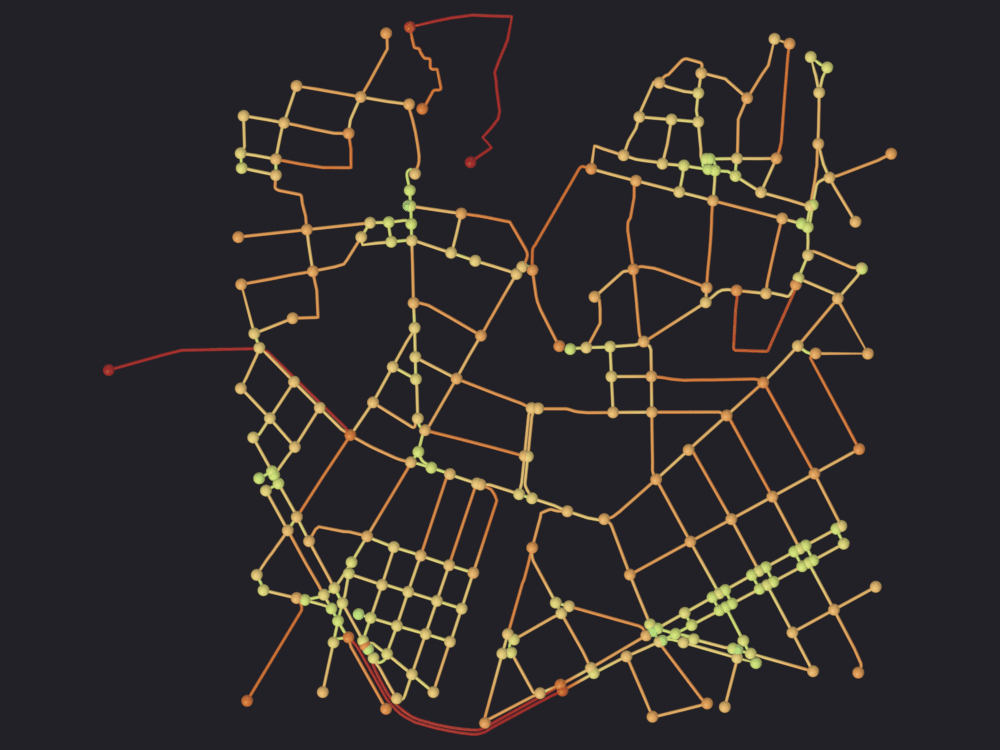

[PASS] 1_length.png legible — 10.1% ink (healthy range 0.5–60%)
ramp mapped: (1.3, 572.3)


In [9]:
print("edge_length_m domain:", sg.render.attribute_domain(vlc, "edge_length_m"))

nb.figure(vlc, f"renders/{RENDERS}/1_length",
          look='ink', color_attribute="edge_length_m",
          clip_high_pct=98)
print("ramp mapped:", tuple(round(v, 1) for v in sg.render.color_range(vlc)))

## 2 · Bearings, and why they are not like the other numbers

`scigraphs.osmnx_add_edge_bearings` puts a compass bearing on every edge:
degrees clockwise from north, 0 to 360, first node to last. It needs an
unprojected graph.

In [10]:
for obj in nets.values():
    sg.graphs.activate(obj)
    bpy.ops.scigraphs.osmnx_add_edge_bearings()

sg.graphs.activate(vlc)
G = graph_cache.get_osmnx_graph(vlc)
bearings = np.array([d["bearing"] for *_e, d in G.edges(data=True)], float)
print(f"bearings on {len(bearings)} edges: "
      f"{bearings.min():.2f}° … {bearings.max():.2f}°, "
      f"none missing: {not np.isnan(bearings).any()}")
print("mesh attributes now:",
      [a.name for a in vlc.data.attributes if a.name.startswith("edge_")])

Edge bearings added to graph
Info: Edge bearings added: 1633 mesh edges
Edge bearings added to graph
Info: Edge bearings added: 1344 mesh edges
Edge bearings added to graph
Info: Edge bearings added: 2334 mesh edges
bearings on 377 edges: 0.07° … 359.31°, none missing: True
mesh attributes now: ['edge_length_m', 'edge_length_m_color', 'edge_bearing']


### The two-point calculator

`scigraphs.osmnx_calculate_bearing_points` is the same computation on typed
coordinates. On an edge with no `geometry`, a straight segment between its
junctions, its answer has to be the edge's own `bearing`.

It has to be a *long* edge. The four coordinate fields are single-precision
`FloatProperty`s, so a latitude near 39.5 is stored to about 2 × 10⁻⁶
degrees, roughly 20 cm on the ground: half a degree of bearing on a 20 m
alley, a hundredth on a 400 m avenue.

In [11]:
straight = [(u, v, d) for u, v, d in G.edges(data=True)
            if d.get("geometry") is None]
for name, (u, v, data) in (("shortest", min(straight, key=lambda e: e[2]["length"])),
                           ("longest", max(straight, key=lambda e: e[2]["length"]))):
    props.osmnx_bearing_lat1, props.osmnx_bearing_lon1 = G.nodes[u]["y"], G.nodes[u]["x"]
    props.osmnx_bearing_lat2, props.osmnx_bearing_lon2 = G.nodes[v]["y"], G.nodes[v]["x"]
    bpy.ops.scigraphs.osmnx_calculate_bearing_points()
    error = abs(props.osmnx_bearing_result - data["bearing"])
    print(f"{name:<9} straight edge, {data['length']:>6.1f} m:  "
          f"graph {data['bearing']:>7.3f}°   operator {props.osmnx_bearing_result:>7.3f}°   "
          f"difference {error:.3f}°")
    if name == "longest":
        longest_error = error

check("the two-point calculator agrees with the edge attribute",
      longest_error < 0.05,
      "on the longest straight edge, where single-precision coordinates "
      "are worth less than a hundredth of a degree of bearing")

Info: Bearing: 130.38°
shortest  straight edge,    1.3 m:  graph 131.058°   operator 130.376°   difference 0.682°
Info: Bearing: 150.87°
longest   straight edge,  124.7 m:  graph 150.844°   operator 150.866°   difference 0.022°
[PASS] the two-point calculator agrees with the edge attribute — on the longest straight edge, where single-precision coordinates are worth less than a hundredth of a degree of bearing


True

### Three traps, and only two of them have a fix

Trap one: the graph is directed, the mesh is not. A two-way street is two
`MultiDiGraph` edges whose bearings differ by 180°, and `build_edge_mapping`
maps `(u,v)` and `(v,u)` to the *same* mesh edge
(`SciGraphs/core/osmnx/mesh_bridge.py:80`), so the last writer wins in
iteration order. The transfer reports 1565 writes onto 1492 mesh edges above,
counting writes rather than edges (`mesh_bridge.py:157`).

Trap two: bearing is circular. 359° and 1° are two degrees apart on the
compass and at opposite ends of any linear ramp, so raw bearing through turbo
splits the north-south streets into dark blue and dark red, two populations
where there is one.

Folding to 0-180° addresses both: `b` and `b + 180` are the same line, so
`b mod 180` is direction-agnostic. Trap one disappears, trap two halves. The
wrap survives: 179.3° and 0.7°, half a degree apart on the ground, are still
at opposite ends of turbo.

In [12]:
def edge_values(obj, attribute):
    """An EDGE-domain float attribute as a numpy array."""
    layer = obj.data.attributes[attribute]
    values = np.zeros(len(layer.data))
    layer.data.foreach_get("value", values)
    return values


def write_edge_attribute(obj, name, values):
    """Create (or replace) an EDGE-domain float attribute."""
    mesh = obj.data
    if name in mesh.attributes:
        mesh.attributes.remove(mesh.attributes[name])
    layer = mesh.attributes.new(name=name, type='FLOAT', domain='EDGE')
    layer.data.foreach_set("value", np.asarray(values, dtype=np.float64))
    return layer


for label, obj in nets.items():
    raw = edge_values(obj, "edge_bearing")
    folded = np.mod(raw, 180.0)
    write_edge_attribute(obj, "edge_bearing_180", folded)
    print(f"{label:<14} raw {raw.min():>6.2f} to {raw.max():>6.2f}°  "
          f"({int((raw > 180).sum())} of {len(raw)} mesh edges above 180°)  "
          f"folded {folded.min():>5.2f} to {folded.max():>6.2f}°")

raw = edge_values(vlc, "edge_bearing")
reciprocal = sum(1 for u, v, _k in G.edges(keys=True) if G.has_edge(v, u))
check("folding makes the direction race harmless",
      np.allclose(np.mod(raw, 180.0), np.mod(raw + 180.0, 180.0)),
      f"{reciprocal} of {G.number_of_edges()} graph edges have a reverse "
      f"twin racing for the same mesh edge; b and b+180 fold to the same "
      f"value, so it stops mattering which one arrived last")

Ciutat Vella   raw   0.07 to 359.31°  (828 of 1560 mesh edges above 180°)  folded  0.07 to 179.31°
Eixample       raw   3.56 to 358.55°  (693 of 1342 mesh edges above 180°)  folded  0.74 to 179.31°
Albaicin       raw   0.25 to 356.34°  (677 of 1443 mesh edges above 180°)  folded  0.25 to 179.52°
[PASS] folding makes the direction race harmless — 28 of 377 graph edges have a reverse twin racing for the same mesh edge; b and b+180 fold to the same value, so it stops mattering which one arrived last


True

### Trap three, and it is the one that decides the figure

A map of the Eixample colored by `edge_bearing_180` comes out beautifully:
two families of street in teal and orange crossing at right angles, the
pre-1884 diagonals in yellow-green. It is not in this notebook.

There is no per-edge color on a graph. Color attributes live only on
`POINT` or `CORNER`, and a graph mesh has no faces, so
`SciGraphs/core/coloring/attributes.py:144` falls through to `POINT` when the
mesh has no loops (`:155`) and `values_for_color_domain` averages the
incident edges at each vertex (`:227`). Each tube is a gradient between two
such averages, and the edge's own value never appears unless both endpoints
average back to it. Most vertices are degree-2 shape points whose two mesh
edges belong to the same street and carry the same value, so a curved
street's interior is exact and its junctions are not.

In [13]:
def averaging_damage(obj, attribute, tolerance=5.0):
    """What an EDGE attribute loses on its way to a vertex color.

    Reproduces `core.coloring.attributes.values_for_color_domain`'s EDGE ->
    POINT fallback: how many vertices land exactly on some incident edge's
    value, how many mesh edges are therefore drawn at their own constant
    color, and how often a mixed vertex averages further than `tolerance`
    from every incident value.
    """
    mesh = obj.data
    values = edge_values(obj, attribute)
    raw_pairs = np.empty(len(mesh.edges) * 2, dtype=np.int32)
    mesh.edges.foreach_get("vertices", raw_pairs)
    pairs = raw_pairs.reshape(-1, 2)

    n = len(mesh.vertices)
    sums, counts = np.zeros(n), np.zeros(n)
    np.add.at(sums, pairs[:, 0], values)
    np.add.at(sums, pairs[:, 1], values)
    np.add.at(counts, pairs[:, 0], 1.0)
    np.add.at(counts, pairs[:, 1], 1.0)
    means = sums / np.where(counts == 0, 1.0, counts)

    exact = np.ones(n, dtype=bool)
    incident = {}
    for (v0, v1), value in zip(pairs, values):
        for vertex in (v0, v1):
            if abs(means[vertex] - value) > 1e-4:
                exact[vertex] = False
            incident.setdefault(vertex, []).append(value)

    constant = sum(1 for (v0, v1), value in zip(pairs, values)
                   if exact[v0] and exact[v1] and abs(means[v0] - value) < 1e-4)
    mixed = [v for v, vals in incident.items()
             if len(set(np.round(vals, 4))) > 1]
    unreal = sum(1 for v in mixed
                 if min(abs(means[v] - x) for x in incident[v]) > tolerance)
    return {
        "vertices": n,
        "exact vertices": int(exact.sum()),
        "mesh edges": len(pairs),
        "constant edges": constant,
        "mixed vertices": len(mixed),
        f"mean >{tolerance:.0f} from every incident": unreal,
    }


eix = nets["Eixample"]
bearing_damage = averaging_damage(eix, "edge_bearing_180")
print("edge_bearing_180 on the Eixample:")
for key, value in bearing_damage.items():
    print(f"   {key:<36} {value}")

edge_bearing_180 on the Eixample:
   vertices                             1176
   exact vertices                       910
   mesh edges                           1342
   constant edges                       596
   mixed vertices                       266
   mean >5 from every incident          254


Three quarters of the vertices are fine, the shape points where
the fallback averages a street's value with itself. Fewer than half the tubes
are drawn at their own constant value; every segment touching a junction
ramps toward that junction's average.

For a linear quantity that is an interpretable blur. For bearing it is a
fabrication: at 95 % of the vertices where two street directions meet, the
average is more than five degrees from every one of them. North-south meeting
east-west averages to 45°, a direction no street there has, drawn as a
diagonal. Folding to 0-180° only changes which fabricated number appears.

So there is no bearing map here. The distribution is in section 3's
orientation rose, where a histogram bins each edge exactly once.

### Deviation from the dominant axis

Take the modal bearing θ₀ and ask of every street how many degrees it is from
the nearest arm of the orthogonal cross through θ₀. The answer is bounded by
0 and 45 and linear: nothing wraps. Zero means the street belongs to the
grid, forty-five means it is on the diagonal.

θ₀ comes from the add-on's `bearing.get_bearings_distribution`, wrapping
OSMnx's binning, which is not the naive one: it splits 36 bins into 72, rolls
by one and merges in pairs, so the first bin runs 355°-5° instead of 0°-10°.
Without the roll a grid aligned to north lands on a bin edge and is split in
half.

In [14]:
def dominant_axis(obj, num_bins=36):
    """The modal bearing of a network, in degrees, from OSMnx's rolled bins."""
    graph = graph_cache.get_osmnx_graph(obj)
    counts, centers = sg_bearing.get_bearings_distribution(graph, num_bins=num_bins)
    return float(centers[int(np.argmax(counts))]), np.asarray(counts)


def axis_deviation(bearings, theta0):
    """Degrees from the nearest arm of the orthogonal cross through `theta0`."""
    within_quadrant = np.mod(bearings - theta0, 90.0)
    return np.minimum(within_quadrant, 90.0 - within_quadrant)


axes, modal_share = {}, {}
for label, obj in nets.items():
    theta0, counts = dominant_axis(obj)
    deviation = axis_deviation(edge_values(obj, "edge_bearing"), theta0)
    write_edge_attribute(obj, "edge_axis_deviation", deviation)
    axes[label] = theta0
    modal_share[label] = float(counts.max() / counts.sum())
    print(f"{label:<14} dominant axis {theta0:>5.1f}°  holding "
          f"{100 * modal_share[label]:>4.1f}% of the edges (uniform would be 2.8%)   "
          f"deviation median {np.median(deviation):>5.2f}°   "
          f"within 5° of the cross {100 * (deviation < 5).mean():>5.1f}%")

Ciutat Vella   dominant axis 330.0°  holding  6.6% of the edges (uniform would be 2.8%)   deviation median 28.35°   within 5° of the cross  15.7%
Eixample       dominant axis 240.0°  holding 16.3% of the edges (uniform would be 2.8%)   deviation median  6.81°   within 5° of the cross  45.2%
Albaicin       dominant axis 150.0°  holding  5.6% of the edges (uniform would be 2.8%)   deviation median 19.36°   within 5° of the cross  18.5%


~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bearings per edge), pass a MultiGraph instead. Use `convert.to_undirected`.
  bearings, weights = _extract_edge_bearings(G, min_length, weight)
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bearings per edge), pass a MultiGraph instead. Use `convert.to_undirected`.
  bearings, weights = _extract_edge_bearings(G, min_length, weight)
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bear

Deviation is bounded and linear, so a vertex mean is a real
number about the streets meeting there, and the junction damage falls from
95 % of mixed vertices to under 30 %.

In [15]:
deviation_damage = averaging_damage(eix, "edge_axis_deviation")
print("edge_axis_deviation on the Eixample:")
for key, value in deviation_damage.items():
    print(f"   {key:<36} {value}")

check("a linear quantity survives the vertex average far better",
      deviation_damage["mean >5 from every incident"]
      < 0.4 * bearing_damage["mean >5 from every incident"],
      "same mesh, same junctions; only the quantity is different")

edge_axis_deviation on the Eixample:
   vertices                             1176
   exact vertices                       910
   mesh edges                           1342
   constant edges                       596
   mixed vertices                       266
   mean >5 from every incident          77
[PASS] a linear quantity survives the vertex average far better — same mesh, same junctions; only the quantity is different


True

  Promoted 3 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> edge_axis_deviation  ·  edge_axis_deviation -> turbo [log]  [0.00386 … 44.92] on Point


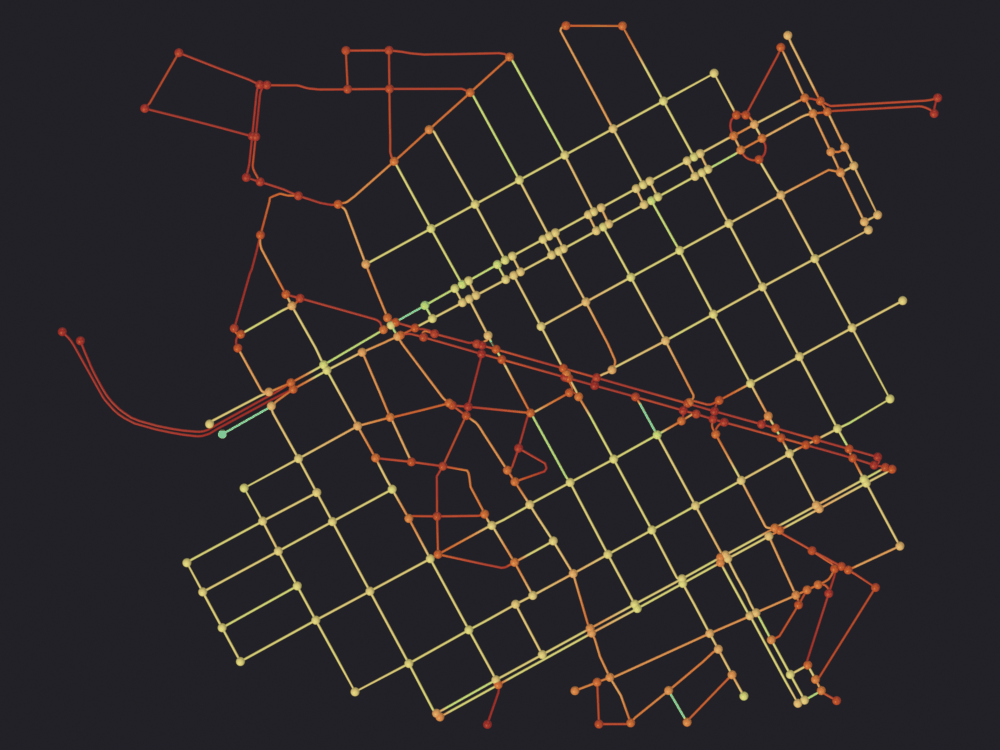

[PASS] 2_deviation_eixample.png legible — 9.7% ink (healthy range 0.5–60%)
Eixample       ramp mapped: (0.0, 44.9)
  Promoted 3 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> edge_axis_deviation  ·  edge_axis_deviation -> turbo [log]  [0.04172 … 44.97] on Point


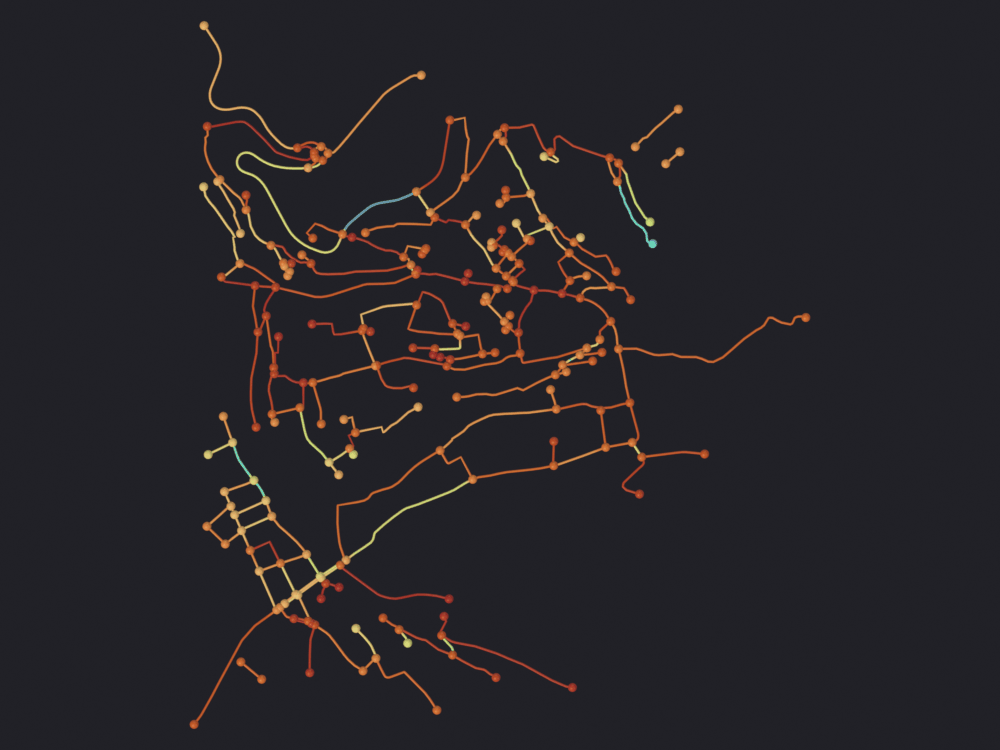

[PASS] 3_deviation_albaicin.png legible — 5.2% ink (healthy range 0.5–60%)
Albaicin       ramp mapped: (0.0, 45.0)


In [16]:
for label, stem in (("Eixample", "2_deviation_eixample"),
                    ("Albaicin", "3_deviation_albaicin")):
    obj = nets[label]
    sg.graphs.activate(obj)
    nb.figure(obj, f"renders/{RENDERS}/{stem}",
              look='ink', color_attribute="edge_axis_deviation")
    print(f"{label:<14} ramp mapped:",
          tuple(round(v, 1) for v in sg.render.color_range(obj)))

Those two frames are the argument of this notebook. The
Eixample is a purple lattice, the grid at deviation ≈ 0, with the older roads
in orange and red because they predate it. The Albaicín is a rainbow: no
color dominates because there is no frame to deviate from. Median deviation
6.8° against 19.0°, same operator, same radius, same scale. The red diagonals
visibly cool where they cross the grid, which is the junction averaging and
not the street turning.

Deviation from θ₀ only means anything if θ₀ does, and the modal bin's share
says whether it does: 16 % of the Eixample's edges in one 10° bin against a
uniform 2.8 %, so its axis is real. Ciutat Vella's modal bin holds under 7 %,
a plurality rather than an axis, so its median deviation of 29° is
meaningless, higher even than the Albaicín's for no reason but which of three
near-equal bins won. Entropy measures whether a dominant axis exists at all.

The shared scale could not have been *imposed*: `vmin`/`vmax` are silently
ineffective, because `scigraphs.color_set_attribute` calls
`update_property_range()` first (`SciGraphs/ui/coloring/operators.py:374`)
and overwrites them. It comes from the quantity being bounded, and the two
printed ranges are the check.

In [17]:
check("the two deviation figures share a scale",
      all(abs(sg.render.color_range(nets[p])[1] - 45.0) < 1.0
      for p in ("Eixample", "Albaicin")),
      "both ramps end within a degree of 45°, so purple means the same "
      "thing in both frames")

[PASS] the two deviation figures share a scale — both ramps end within a degree of 45°, so purple means the same thing in both frames


True

## 3 · Orientation entropy

Bin the bearings into 36 bins of 10° and take the Shannon entropy. A network
whose streets run in every direction equally has the maximum,
ln 36 = 3.5835 nats; a perfect four-armed grid fills four bins and has
ln 4 = 1.3863.

Boeing (2019) turns the two bounds into one number, *orientation-order*
φ = 1 − ((H − H_grid) / (H_max − H_grid))², which is 1 for a perfect grid and
0 for a perfectly disordered network.

In [18]:
H_MAX = math.log(36)
H_GRID = math.log(4)


def orientation_order(entropy):
    return 1.0 - ((entropy - H_GRID) / (H_MAX - H_GRID)) ** 2


rows = []
for label, obj in nets.items():
    sg.graphs.activate(obj)
    bpy.ops.scigraphs.osmnx_orientation_entropy()
    H = float(obj["orientation_entropy"])
    rows.append({
                "place": label,
                "edges": obj["num_edges"],
                "H (nats)": round(H, 4),
                "H / Hmax": round(H / H_MAX, 4),
                "phi": round(orientation_order(H), 4),
                "axis": axes[label],
                "modal bin %": round(100 * modal_share[label], 1),
                "median dev": round(float(np.median(edge_values(obj, "edge_axis_deviation"))), 2),
                })

entropy_table = pd.DataFrame(rows).set_index("place")
print(f"H_max = ln 36 = {H_MAX:.4f}    H_grid = ln 4 = {H_GRID:.4f}\n")
print(entropy_table.to_string())

Orientation entropy: 3.3654
Info: Orientation entropy: 3.3654
Orientation entropy: 2.7641
Info: Orientation entropy: 2.7641
Orientation entropy: 3.5009
Info: Orientation entropy: 3.5009
H_max = ln 36 = 3.5835    H_grid = ln 4 = 1.3863

              edges  H (nats)  H / Hmax     phi   axis  modal bin %  median dev
place                                                                          
Ciutat Vella    377    3.3654    0.9391  0.1887  330.0          6.6       28.35
Eixample        443    2.7641    0.7713  0.6068  240.0         16.3        6.81
Albaicin        411    3.5009    0.9770  0.0738  150.0          5.6       19.36


~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bearings per edge), pass a MultiGraph instead. Use `convert.to_undirected`.
  bearings, weights = _extract_edge_bearings(G, min_length, weight)
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bearings per edge), pass a MultiGraph instead. Use `convert.to_undirected`.
  bearings, weights = _extract_edge_bearings(G, min_length, weight)
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bear

The Albaicín reaches 97.7 % of the maximum entropy a 36-bin
histogram can carry: its streets are, to within a couple of percent,
uniformly distributed over the compass. The Eixample sits at 77 %, and its φ
of 0.61 is the largest of the three by a factor of three. Ciutat Vella lands
between them and much closer to the Albaicín: the medieval core dominates the
sample and the grid is only its southern fringe.

The number is directional. OSMnx warns that a `MultiDiGraph` yields one
bearing per *directed* edge, so a two-way street votes twice, at b and at
b + 180, while a one-way street votes once. On a mostly two-way network that
is close to a uniform doubling; with many one-way streets it is a real bias,
and converting to an undirected multigraph first removes it.

It can also be length-weighted. `weight="length"` counts meters of street
rather than segments, which stops a warren of short alleys outvoting a
boulevard. Neither option is exposed by the operator or the panel; both are
one argument away in the library.

In [19]:
for label, obj in nets.items():
    graph = graph_cache.get_osmnx_graph(obj)
    undirected = ox.convert.to_undirected(graph)
    H_dir = ox.bearing.orientation_entropy(graph)
    H_und = ox.bearing.orientation_entropy(undirected)
    H_len = ox.bearing.orientation_entropy(graph, weight="length")
    print(f"{label:<14} directed {H_dir:.4f}   undirected {H_und:.4f}   "
          f"length-weighted {H_len:.4f}    "
          f"phi {orientation_order(H_dir):.3f} / {orientation_order(H_und):.3f} / "
          f"{orientation_order(H_len):.3f}")

Ciutat Vella   directed 3.3654   undirected 3.3830   length-weighted 3.3845    phi 0.189 / 0.174 / 0.173
Eixample       directed 2.7641   undirected 2.7837   length-weighted 2.7384    phi 0.607 / 0.596 / 0.621
Albaicin       directed 3.5009   undirected 3.5118   length-weighted 3.4514    phi 0.074 / 0.064 / 0.117


~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bearings per edge), pass a MultiGraph instead. Use `convert.to_undirected`.
  bearings, weights = _extract_edge_bearings(G, min_length, weight)
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bearings per edge), pass a MultiGraph instead. Use `convert.to_undirected`.
  bearings, weights = _extract_edge_bearings(G, min_length, weight)
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bear

### Two entropies, one object

`osmnx_add_edge_bearings` also writes `osmnx_bearing_entropy`, from the
add-on's own `get_bearing_distribution` (`SciGraphs/core/osmnx/stats.py:78`),
with plain `np.histogram` bins at 0°, 10°, 20°…, no roll, normalized by
log₂ 36. `osmnx_orientation_entropy` writes `orientation_entropy`, OSMnx's,
in nats with rolled bins. Same statistic, different units and binning,
similar names on the same object, and nothing says which is which.

In [20]:
for label, obj in nets.items():
    naive = float(obj["osmnx_bearing_entropy"])
    rolled = float(obj["orientation_entropy"]) / H_MAX
    print(f"{label:<14} osmnx_bearing_entropy {naive:.4f} (naive bins, log2)  vs  "
          f"orientation_entropy/Hmax {rolled:.4f} (rolled bins)   "
          f"delta {naive - rolled:+.4f}")

check("the two normalized entropies agree to within 0.02",
      all(abs(float(o["osmnx_bearing_entropy"])
      - float(o["orientation_entropy"]) / H_MAX) < 0.02
      for o in nets.values()),
      "close, but they are not the same computation and neither name says so")

Ciutat Vella   osmnx_bearing_entropy 0.9260 (naive bins, log2)  vs  orientation_entropy/Hmax 0.9391 (rolled bins)   delta -0.0131
Eixample       osmnx_bearing_entropy 0.7700 (naive bins, log2)  vs  orientation_entropy/Hmax 0.7713 (rolled bins)   delta -0.0013
Albaicin       osmnx_bearing_entropy 0.9800 (naive bins, log2)  vs  orientation_entropy/Hmax 0.9770 (rolled bins)   delta +0.0030
[PASS] the two normalized entropies agree to within 0.02 — close, but they are not the same computation and neither name says so


True

### The histogram operator

`scigraphs.osmnx_bearings_distribution` computes the rolled 36-bin histogram
and stores it as a string that cannot be read back: the counts are a numpy
array, so `str(list(counts))` produces
`"[np.float64(3.0), np.float64(10.0), …]"`, which `ast.literal_eval` rejects
(`SciGraphs/ui/operators/osmnx/graph_operators.py:937`). Recovering them
means a regex over the repr, or calling
`core.osmnx.bearing.get_bearings_distribution` yourself, as `dominant_axis`
above does.

In [21]:
sg.graphs.activate(eix)
props.osmnx_bearing_num_bins = 36
print("osmnx_bearings_distribution ->", bpy.ops.scigraphs.osmnx_bearings_distribution())
stored = eix["bearing_distribution"]
print(f"stored as {type(stored).__name__}: {stored[:72]}…")
try:
    ast.literal_eval(stored)
    parsed = True
except (ValueError, SyntaxError) as exc:
    parsed = False
    print("ast.literal_eval ->", type(exc).__name__)

check("the stored histogram is not machine-readable", not parsed,
      "the same counts come back cleanly from "
      "core.osmnx.bearing.get_bearings_distribution")

Info: Bearing distribution calculated (36 bins)
osmnx_bearings_distribution -> {'FINISHED'}
stored as str: [np.float64(3.0), np.float64(10.0), np.float64(4.0), np.float64(3.0), np…
ast.literal_eval -> ValueError
[PASS] the stored histogram is not machine-readable — the same counts come back cleanly from core.osmnx.bearing.get_bearings_distribution


~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/osmnx/bearing.py:282: UserWarning: `G` is a MultiDiGraph, so edge bearings will be directional (one per edge). If you want bidirectional edge bearings (two reciprocal bearings per edge), pass a MultiGraph instead. Use `convert.to_undirected`.
  bearings, weights = _extract_edge_bearings(G, min_length, weight)


True

### The orientation rose

`scigraphs.osmnx_orientation_rose` draws the polar histogram and produces no
scene geometry: a 900 × 900 Pillow PNG (concentric grid, compass labels, one
wedge per bin) written to the system temp directory, loaded as a
`bpy.data.images` datablock, packed, and pushed into any open Image Editor.
What follows is that image, copied out of temp.

- the temp filename is `<object name>_orientation_rose.png`, so two networks
  both called `OSMnx_StreetNetwork` (the default) silently overwrite each
  other's rose, which is why `import_network` renames every import;
- it bins naively, like `get_bearing_distribution` above, so a grid aligned
  to north lands on a bin edge and comes out as eight lobes instead of four;
- `osmnx_rose_radius` and `osmnx_rose_height_scale` are registered
  properties, documented as belonging to "the 3D orientation rose", and the
  operator reads neither. The 3D version exists in
  `SciGraphs/core/osmnx/centrality.py:308` and nothing calls it.

It also reads the live graph (`_pick_graph`, `centrality_operators.py:14`)
and fails without bearings on it, where `osmnx_orientation_entropy` and
`osmnx_bearings_distribution` read the unprojected snapshot the importer
froze at download time (`ui/operators/scigraphs/data_operators.py:643`) and
quietly recompute bearings through `bearing._ensure_bearings`
(`core/osmnx/bearing.py:5`), so they work whether or not you ran
`Add Edge Bearings`.

In [22]:
rose_paths = {}
for label, obj in nets.items():
    sg.graphs.activate(obj)
    props.osmnx_rose_bins = 36
    bpy.ops.scigraphs.osmnx_orientation_rose()
    image = bpy.data.images[f"{obj.name}_orientation_rose"]
    destination = nb.out(
        f"renders/{RENDERS}/rose_{label.lower().replace(' ', '')}.png")
    shutil.copyfile(bpy.path.abspath(image.filepath), destination)
    rose_paths[label] = destination
    print(f"{label:<14} {image.size[0]}x{image.size[1]} px, "
          f"packed={bool(image.packed_file)}  ->  {destination.name}")

Info: Orientation rose: 377 bearings, 36 bins → image 'Streets_CiutatVella_orientation_rose'
Ciutat Vella   900x900 px, packed=True  ->  rose_ciutatvella.png
Info: Orientation rose: 443 bearings, 36 bins → image 'Streets_Eixample_orientation_rose'
Eixample       900x900 px, packed=True  ->  rose_eixample.png
Info: Orientation rose: 411 bearings, 36 bins → image 'Streets_Albaicin_orientation_rose'
Albaicin       900x900 px, packed=True  ->  rose_albaicin.png


Ciutat Vella  ·  orientation entropy 3.3654 nats, phi 0.189


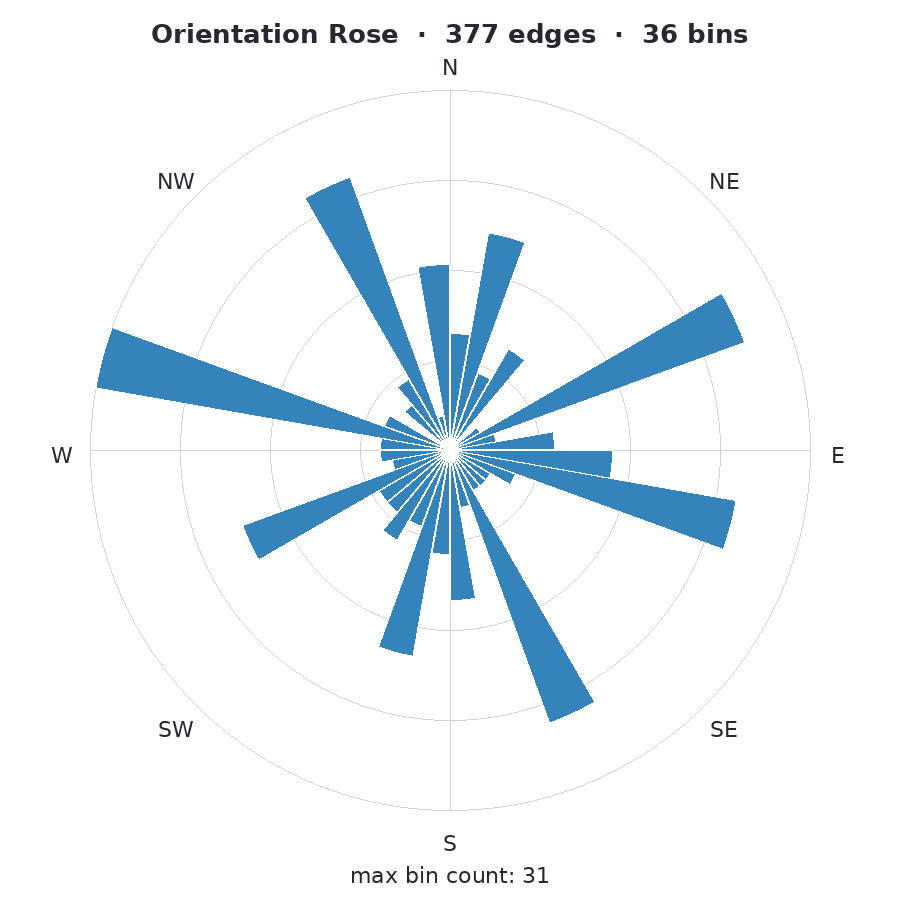

[PASS] rose_ciutatvella.png legible — 9.7% ink (healthy range 0.5–60%)
Eixample  ·  orientation entropy 2.7641 nats, phi 0.607


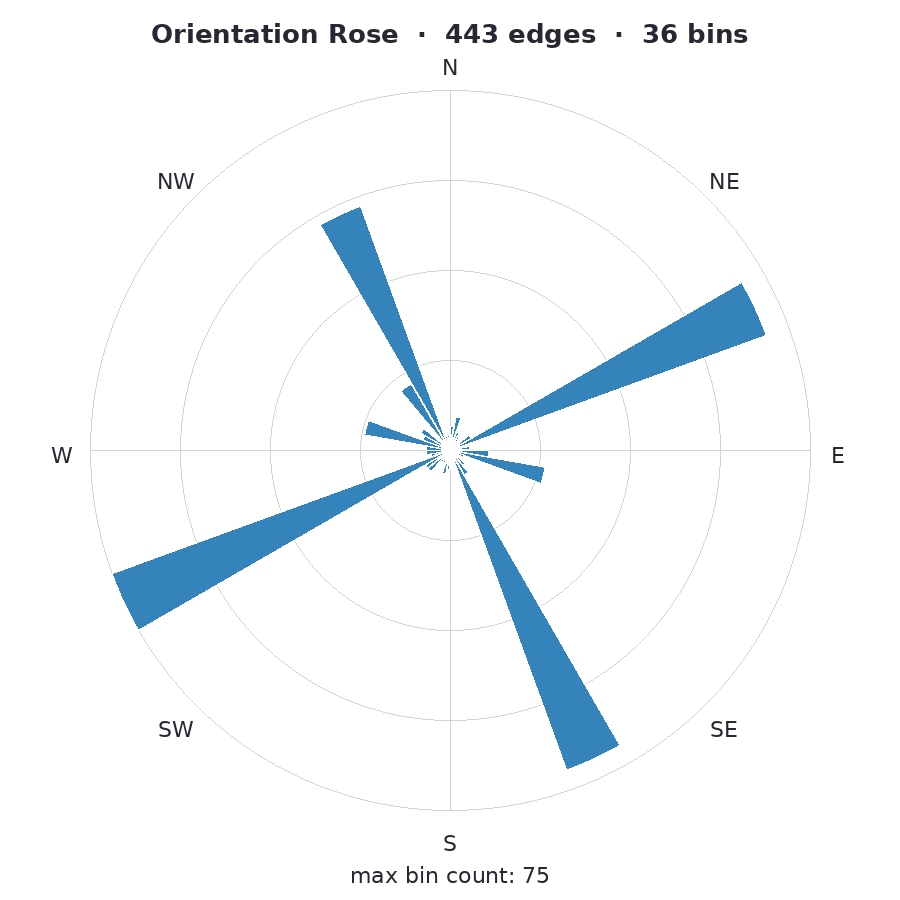

[PASS] rose_eixample.png legible — 6.2% ink (healthy range 0.5–60%)
Albaicin  ·  orientation entropy 3.5009 nats, phi 0.074


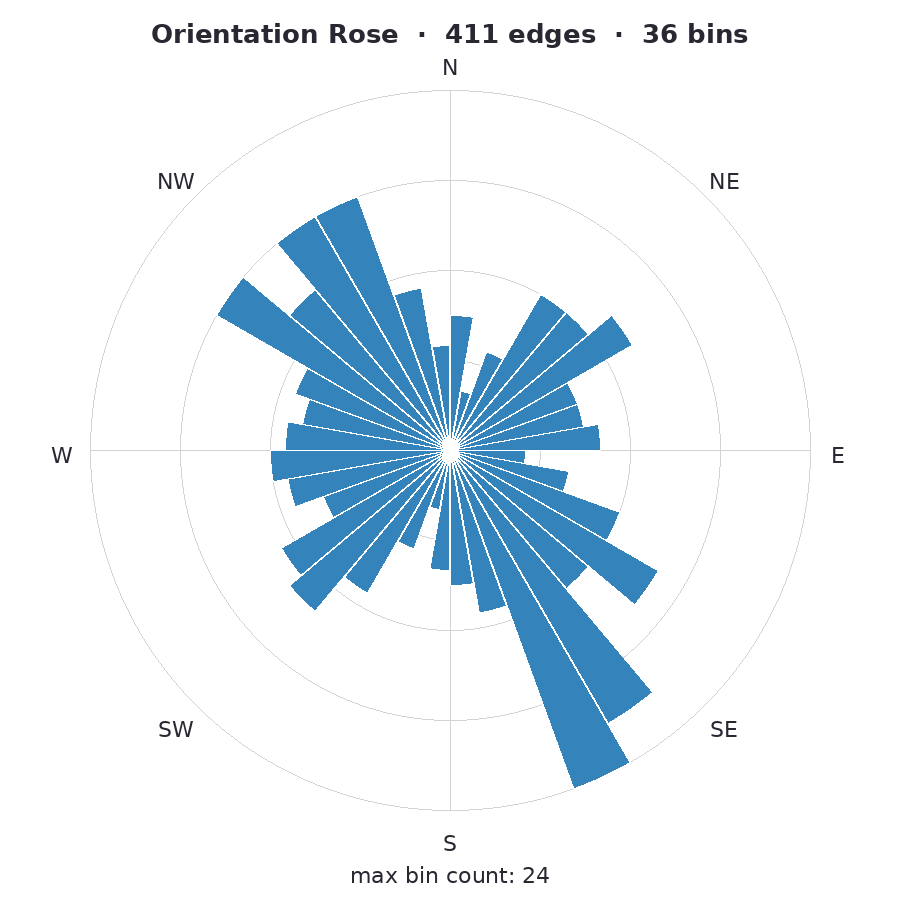

[PASS] rose_albaicin.png legible — 13.3% ink (healthy range 0.5–60%)


In [23]:
for label, path in rose_paths.items():
    print(f"{label}  ·  orientation entropy "
          f"{entropy_table.loc[label, 'H (nats)']:.4f} nats, "
          f"phi {entropy_table.loc[label, 'phi']:.3f}")
    nb.show(path)
    nb.check_render(path)

Four clean lobes for the Eixample against a near-complete disc
for the Albaicín. Ciutat Vella is neither: eight or so competing spokes of
similar length, several strong directions and no winner, the shape that gives
a high entropy and a meaningless dominant axis.

The bin counts differ slightly from section 2's, the naive binning showing:
this rose's largest bin holds 31 edges where OSMnx's rolled bins put 25 in
the biggest.

## 4 · Speeds, and how much of them is guessed

`scigraphs.osmnx_add_edge_speeds` gives every edge a `speed_kph`. Where OSM
carries a `maxspeed` tag it uses it, converting mph to km/h when the string
says so. Where it does not, which is most residential streets, it imputes,
and nothing downstream says which edges got which:

1. clean the `maxspeed` strings into numbers; anything unparseable becomes
   missing;
2. for each `highway` type, take the mean of the speeds that survived;
3. fill every missing edge with the mean of its own highway type;
4. for a highway type with no usable `maxspeed` on any of its edges, fall
   back to the panel's `osmnx_fallback_speed`, 30 km/h by default;
5. if even that is unavailable, the mean of the type means.

So an untagged residential street inherits the average of the tagged ones in
*this download*: a property of the bounding box as much as of the street. The
add-on strips any pre-existing `speed_kph` before calling OSMnx
(`SciGraphs/core/osmnx/edge_attributes.py:163`), so re-running with a
different fallback takes effect.

### Measuring the imputed fraction

There is no flag, so it has to be recovered: run the imputation a second time
with a sentinel as the per-type default, through the public `hwy_speeds` and
`fallback` arguments. Any edge that comes back holding a sentinel was filled
in rather than read off the map.

In [24]:
def highway_of(data):
    highway = data.get("highway")
    return highway[0] if isinstance(highway, list) else highway


def imputation_flags(graph):
    """{(u, v, k): 1.0 if `speed_kph` would be imputed else 0.0}, and the types."""
    types = Counter(highway_of(d) for *_e, d in graph.edges(data=True))
    sentinels = {name: -1000.0 - i for i, name in enumerate(sorted(types))}
    probed = ox.add_edge_speeds(graph.copy(), hwy_speeds=sentinels, fallback=-1.0)
    flags = {(u, v, k): float(d["speed_kph"] < 0)
             for u, v, k, d in probed.edges(keys=True, data=True)}
    return flags, types


speed_rows = []
for label, obj in nets.items():
    sg.graphs.activate(obj)
    graph = graph_cache.get_osmnx_graph(obj)
    flags, types = imputation_flags(graph)

    tagged = sum(1 for *_e, d in graph.edges(data=True)
                 if d.get("maxspeed") is not None)
    typed_with_maxspeed = {highway_of(d) for *_e, d in graph.edges(data=True)
                           if d.get("maxspeed") is not None}
    from_fallback = sum(count for name, count in types.items()
                        if name not in typed_with_maxspeed)

    # Through the add-on's own bridge, and before the speed operator replaces
    # the graph object in the cache.
    flagged = graph.copy()
    for _u, _v, key, data in flagged.edges(keys=True, data=True):
        data["speed_imputed"] = flags[(_u, _v, key)]
    mesh_bridge.transfer_edge_attribute_to_mesh(
        obj, flagged, "speed_imputed", "edge_speed_imputed")

    bpy.ops.scigraphs.osmnx_add_edge_speeds()
    speeds = np.array([d["speed_kph"] for *_e, d
                      in graph_cache.get_osmnx_graph(obj).edges(data=True)], float)

    speed_rows.append({
                      "place": label,
                      "edges": len(flags),
                      "maxspeed tag": tagged,
                      "imputed": int(sum(flags.values())),
                      "imputed %": round(100 * sum(flags.values()) / len(flags), 1),
                      "from fallback": from_fallback,
                      # One decimal, not two: the accumulation order of an
                      # imputed mean varies between processes, so the last
                      # digit of a type mean is not reproducible.
                      "mean kph": round(float(speeds.mean()), 1),
                      })

speed_table = pd.DataFrame(speed_rows).set_index("place")
print(f"fallback speed on the panel: {props.osmnx_fallback_speed} km/h\n")
print(speed_table.to_string())

Edge speeds added (fallback: 30 km/h)
Info: Edge speeds added: 377/377 graph edges, 1633 mesh edges updated (fallback: 30 km/h)
Edge speeds added (fallback: 30 km/h)
Info: Edge speeds added: 443/443 graph edges, 1344 mesh edges updated (fallback: 30 km/h)
Edge speeds added (fallback: 30 km/h)
Info: Edge speeds added: 411/411 graph edges, 2334 mesh edges updated (fallback: 30 km/h)
fallback speed on the panel: 30 km/h

              edges  maxspeed tag  imputed  imputed %  from fallback  mean kph
place                                                                         
Ciutat Vella    377           270      107       28.4              9      32.7
Eixample        443           302      141       31.8             18      37.3
Albaicin        411           397       14        3.4              0      23.1


A little over a quarter of Ciutat Vella's segments and nearly a
third of the Eixample's carry a speed nobody mapped. The Albaicín is the
outlier at 3 %, because almost every street in it is tagged `living_street`,
and in Granada those come with a speed.

The `from fallback` column is the sharper number: edges whose entire *highway
type* had no usable `maxspeed` anywhere in the download, slip roads mostly,
so they got the flat 30 km/h off the panel rather than even a plausible type
average.

[PASS] the imputed fraction is large enough to matter — a travel time computed from an imputed speed is a much weaker number than one computed from a mapped maxspeed, and nothing on the object distinguishes them
mesh edges flagged imputed: 386 of 1560 (24.7 %)
  Promoted 6 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> edge_speed_imputed  ·  edge_speed_imputed -> turbo [log]  [0 … 1] on Point


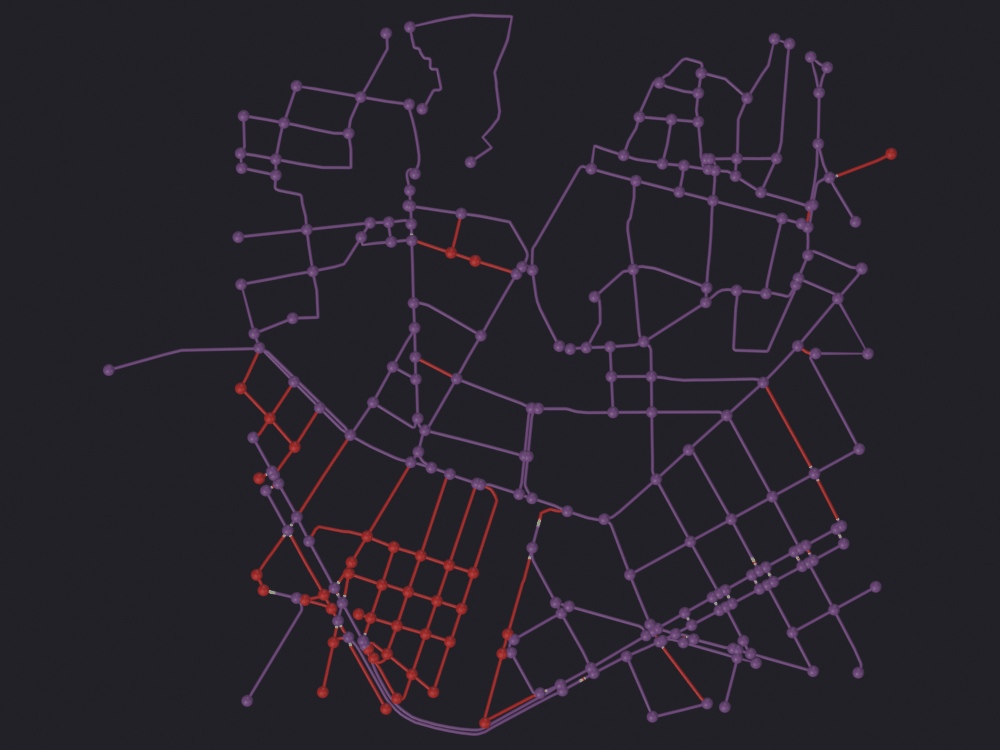

[PASS] 4_imputed.png legible — 9.4% ink (healthy range 0.5–60%)


In [25]:
check("the imputed fraction is large enough to matter",
      speed_table.loc["Ciutat Vella", "imputed %"] > 20,
      "a travel time computed from an imputed speed is a much weaker "
      "number than one computed from a mapped maxspeed, and nothing on "
      "the object distinguishes them")

sg.graphs.activate(vlc)
mask = edge_values(vlc, "edge_speed_imputed")
print(f"mesh edges flagged imputed: {int((mask > 0.5).sum())} of {len(mask)} "
      f"({100 * (mask > 0.5).mean():.1f} %)")

nb.figure(vlc, f"renders/{RENDERS}/4_imputed",
          look='ink', color_attribute="edge_speed_imputed")

Red is imputed, purple is mapped, and they are not sprinkled at
random: the guessed speeds are concentrated in the south-western quarter, in
the grid and the streets feeding it, while the medieval core is almost
entirely tagged. Any travel-time surface over this network is far weaker in
one corner, and no scalar summary would say so.

The node spheres take the mean of their incident edges, because
`render_eevee` promotes edge attributes to the point domain to survive the
curve conversion. A teal or yellow junction is where mapped and imputed
streets meet, which on a 0/1 mask is the right reading.

### Travel time

`scigraphs.osmnx_add_travel_times` divides `length` by `speed_kph` and writes
seconds: a geodetic length, an often-imputed speed, and no record of which is
which.

Edge travel times added to graph
Info: Travel times added: 377/377 graph edges, 1633 mesh edges updated
osmnx_add_travel_times -> {'FINISHED'}
travel_time  mean 10.58 s   median 8.86 s   max 103.02 s   total 66.5 min
[PASS] travel_time is length over speed — seconds, from meters and km/h, unrounded
  Promoted 7 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> edge_travel_time  ·  edge_travel_time -> turbo [log]  [0.1585 … 50.97] on Point


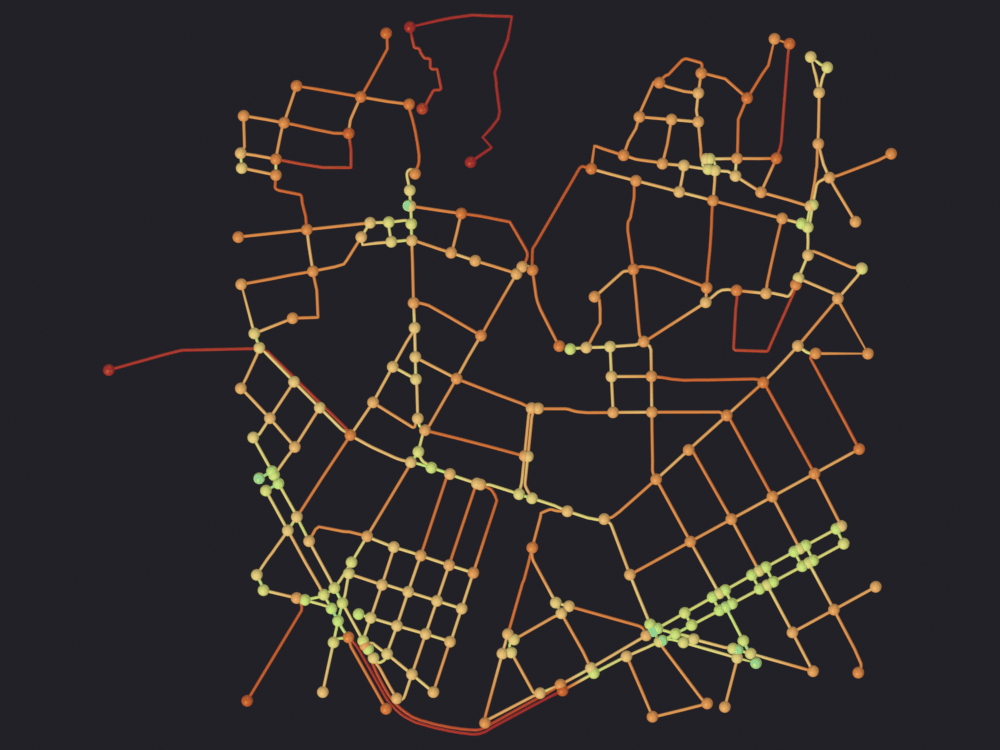

[PASS] 5_travel_time.png legible — 10.1% ink (healthy range 0.5–60%)
ramp mapped: (0.16, 50.97)


In [26]:
sg.graphs.activate(vlc)
print("osmnx_add_travel_times ->", bpy.ops.scigraphs.osmnx_add_travel_times())

G = graph_cache.get_osmnx_graph(vlc)
travel = np.array([d["travel_time"] for *_e, d in G.edges(data=True)], float)
speeds = np.array([d["speed_kph"] for *_e, d in G.edges(data=True)], float)
lengths = np.array([d["length"] for *_e, d in G.edges(data=True)], float)

print(f"travel_time  mean {travel.mean():.2f} s   median {np.median(travel):.2f} s   "
      f"max {travel.max():.2f} s   total {travel.sum() / 60:.1f} min")
check("travel_time is length over speed",
      np.allclose(travel, lengths / (speeds * 1000 / 3600), rtol=1e-6),
      "seconds, from meters and km/h, unrounded")

nb.figure(vlc, f"renders/{RENDERS}/5_travel_time",
          look='ink', color_attribute="edge_travel_time",
          clip_high_pct=98)
print("ramp mapped:", tuple(round(v, 2) for v in sg.render.color_range(vlc)))

The ramp is visibly better spread than the length figure's: the
long streets are also the fast ones, so dividing by speed compresses exactly
the tail that made the length distribution awkward, and the same 98 % clip
now covers a range the median street sits inside.

What to do with `travel_time`, shortest paths, isochrones, k-shortest routes,
is notebook 08.

## 5 · Circuity

Circuity is network distance over straight-line distance: every edge's
`length` summed, over the great-circle distances between the same edges'
endpoints. One means every street is a straight line between its junctions;
above one means you walk further than the crow.

`scigraphs.osmnx_circuity` converts to undirected first, so a two-way street
is not counted twice on both sides of the ratio, then calls OSMnx's
`circuity_avg`.

In [27]:
circuity = {}
for label, obj in nets.items():
    sg.graphs.activate(obj)
    bpy.ops.scigraphs.osmnx_circuity()
    circuity[label] = float(obj["circuity_avg"])
    print(f"{label:<14} circuity {circuity[label]:.4f}   "
          f"({100 * (circuity[label] - 1):.2f} % further than the straight line)")

Converted to undirected graph
Circuity calculated: 1.051
Info: Average circuity: 1.051
Ciutat Vella   circuity 1.0506   (5.06 % further than the straight line)
Converted to undirected graph
Circuity calculated: 1.015
Info: Average circuity: 1.015
Eixample       circuity 1.0149   (1.49 % further than the straight line)
Converted to undirected graph
Circuity calculated: 1.090
Info: Average circuity: 1.090
Albaicin       circuity 1.0898   (8.98 % further than the straight line)


The same ratio section 1 already had without naming it.
Checking it also confirms that `circuity_avg` uses the endpoints of the
*simplified* edges and not their shape points.

In [28]:
sg.graphs.activate(vlc)
G = graph_cache.get_osmnx_graph(vlc)
uv = [(u, v) for u, v, _k in G.edges(keys=True)]
straight = ox.distance.great_circle(
    np.array([G.nodes[u]["y"] for u, _v in uv]),
    np.array([G.nodes[u]["x"] for u, _v in uv]),
    np.array([G.nodes[v]["y"] for _u, v in uv]),
    np.array([G.nodes[v]["x"] for _u, v in uv]))
by_hand = float(np.array([d["length"] for *_e, d in G.edges(data=True)]).sum()
                / straight.sum())
print(f"by hand, on the directed graph   {by_hand:.4f}")
print(f"operator, on the undirected one  {circuity['Ciutat Vella']:.4f}")

check("circuity is network length over straight-line distance",
      abs(by_hand - circuity["Ciutat Vella"]) < 0.01)

by hand, on the directed graph   1.0495
operator, on the undirected one  1.0506
[PASS] circuity is network length over straight-line distance


True

The three numbers rank the way the roses do, for a different
reason. The Eixample is 1.5 % longer than straight: a grid's segments *are*
straight lines between junctions, and the residue is chamfered corners.
Ciutat Vella is 4 %. The Albaicín is 9 %: its streets curl around a hillside,
so the line between two junctions 100 m apart is 109 m of street.

Entropy asks *which way* the streets point; circuity asks *how straight* they
are. A regular grid rotated a few degrees per block would have high entropy
and low circuity. The Albaicín has both.

In [29]:
print(pd.DataFrame({
      "H (nats)": entropy_table["H (nats)"],
      "phi": entropy_table["phi"],
      "median deviation": entropy_table["median dev"],
      "circuity": pd.Series(circuity),
      "imputed %": speed_table["imputed %"],
}).to_string())

              H (nats)     phi  median deviation  circuity  imputed %
Ciutat Vella    3.3654  0.1887             28.35  1.050610       28.4
Eixample        2.7641  0.6068              6.81  1.014855       31.8
Albaicin        3.5009  0.0738             19.36  1.089811        3.4


## 6 · `osmnx_attr_to_colors`, and the path this suite uses

| | `osmnx_attr_to_colors` | `nb.figure(color_attribute=…)` |
|---|---|---|
| What it writes | a color attribute on the mesh, RGBA baked per element | a material whose shader reproduces the ramp, plus the color attribute |
| Normalization | min to max of the raw values, fixed at write time | percentile clipping, log and gamma norms, and the mapped range reported back |
| Colormap | `osmnx_colormap`, nine choices | any matplotlib colormap; defaults to the one the `look` names |
| Survives a Geometry Nodes rebuild | no | yes, via `protect_attribute` and `_restore_coloring` |
| EDGE source | a `CORNER` layer with zero elements | the `POINT` fallback of section 2, measured |

The last row is where they part company. `core.coloring.attributes` notices
the mesh has no loops and falls back to `POINT`, averaging at the vertices
(`attributes.py:155`, `:227`): lossy, measured in section 2, but it draws
something. `osmnx_attr_to_colors` goes to `'CORNER'` unconditionally
(`SciGraphs/ui/operators/osmnx/centrality_operators.py:190`), so on a mesh
with no faces it creates a layer with zero elements, and the branch that
would fill them writes a flat 0.5 gray anyway (`:202`). It reports success,
with a count of the colors it computed and threw away.

Both use the name `<attribute>_color`, and the operator removes any existing
layer of that name first (`centrality_operators.py:187`), so running it on an
attribute a figure was drawn from deletes the working colors and replaces
them with nothing, as it does below to the travel-time layer.

In [30]:
sg.graphs.activate(vlc)
print("before:")
for layer in vlc.data.color_attributes:
    print(f"   '{layer.name}'  domain {layer.domain}  elements {len(layer.data)}")

props.osmnx_color_attr_name = "edge_travel_time"
props.osmnx_colormap = 'turbo'
print("\nosmnx_attr_to_colors ->", bpy.ops.scigraphs.osmnx_attr_to_colors())

print("\nafter:")
for layer in vlc.data.color_attributes:
    print(f"   '{layer.name}'  domain {layer.domain}  elements {len(layer.data)}")
print(f"\nmesh polygons {len(vlc.data.polygons)}, loops {len(vlc.data.loops)}")

overwritten = vlc.data.color_attributes["edge_travel_time_color"]
check("the operator's edge branch replaces working colors with none",
      overwritten.domain == 'CORNER' and len(overwritten.data) == 0,
      "an edge-only mesh has no corners, so the layer it creates is empty; "
      "every edge figure in this notebook went through sg.render instead")

before:
   'edge_length_m_color'  domain POINT  elements 1443
   'edge_speed_imputed_color'  domain POINT  elements 1443
   'edge_travel_time_color'  domain POINT  elements 1443
Info: Applied 1560 colors to 'edge_travel_time_color'

osmnx_attr_to_colors -> {'FINISHED'}

after:
   'edge_length_m_color'  domain POINT  elements 1443
   'edge_speed_imputed_color'  domain POINT  elements 1443
   'edge_travel_time_color'  domain CORNER  elements 0

mesh polygons 0, loops 0
[PASS] the operator's edge branch replaces working colors with none — an edge-only mesh has no corners, so the layer it creates is empty; every edge figure in this notebook went through sg.render instead


True

> There is no working route through the POINT branch on a fresh
> OSMnx import either: the operator requires a `FLOAT` attribute, and the
> only vertex layer the importer writes is `is_intersection`, an `INT`.
> Notebook 10 computes node centralities, where a float POINT attribute first
> exists and the operator's working half can be used.

## 7 · `osmnx_add_edge_lengths`, and why it is last

`scigraphs.osmnx_add_edge_lengths` sits at the top of the same panel and
recomputes the `length` everything above used. On an unprojected graph it
does not do what its label says: it takes the edge's `geometry.length` when
there is one and the euclidean distance between node coordinates when there
is not (`SciGraphs/core/osmnx/edge_attributes.py:44-51`), both in whatever
units the coordinates are in. The graph is in EPSG:4326, so the units are
degrees.

It runs here on a throwaway fourth import, because running it on any of the
three above would silently invalidate sections 4 and 5. That, rather than the
degrees, is the part to carry away: it has to run after a projection, or not
at all.

In [31]:
demo = import_network(39.4699, -0.3763, 600, "Streets_LengthDemo")
sg.graphs.activate(demo)
G_demo = graph_cache.get_osmnx_graph(demo)

before = np.array([d["length"] for *_e, d in G_demo.edges(data=True)], float)
bpy.ops.scigraphs.osmnx_add_edge_speeds()
bpy.ops.scigraphs.osmnx_add_travel_times()
travel_before = np.array([d["travel_time"] for *_e, d
                         in graph_cache.get_osmnx_graph(demo).edges(data=True)], float)
bpy.ops.scigraphs.osmnx_circuity()
circuity_before = float(demo["circuity_avg"])

print("osmnx_add_edge_lengths ->", bpy.ops.scigraphs.osmnx_add_edge_lengths())

after = np.array([d["length"] for *_e, d
                 in graph_cache.get_osmnx_graph(demo).edges(data=True)], float)
bpy.ops.scigraphs.osmnx_add_travel_times()
travel_after = np.array([d["travel_time"] for *_e, d
                        in graph_cache.get_osmnx_graph(demo).edges(data=True)], float)
bpy.ops.scigraphs.osmnx_circuity()
circuity_after = float(demo["circuity_avg"])

print(f"\n{'':<16}{'before':>16}{'after':>16}")
print(f"{'mean length':<16}{before.mean():>16.2f}{after.mean():>16.8f}")
print(f"{'mean travel (s)':<16}{travel_before.mean():>16.2f}{travel_after.mean():>16.8f}")
print(f"{'circuity':<16}{circuity_before:>16.4f}{circuity_after:>16.8f}")
print(f"\nratio after/before on length: {after.mean() / before.mean():.3e}, "
      f"one unit is about {before.mean() / after.mean():,.0f} m here, so these "
      f"are degrees")

check("osmnx_add_edge_lengths writes degrees onto an unprojected graph",
      after.mean() < 0.01 < before.mean(),
      "meters before, degrees after; the travel times and the circuity "
      "recomputed afterwards are wrong by the same factor and raise "
      "nothing")


  retain_all: True (disconnected components kept)
  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 0.28s
Total import time: 0.31s
  Nodes: 246, Edges: 377

Creating OSMnx graph: 246 nodes, 377 edges...
  Created 246 intersection vertices
  Created 363 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_drive.graphml
Info: Imported: 246 intersections, 377 street segments, 32.6 km total
Edge speeds added (fallback: 30 km/h)
Info: Edge speeds added: 377/377 graph edges, 1633 mesh edges updated (fallback: 30 km/h)
Edge travel times added to graph
Info: Travel times added: 377/377 graph edges, 1633 mesh edges updated
Converted to undirected g

True

> The fix is one call away and the panel offers it:
> `scigraphs.osmnx_project_graph` first, then Add Edge Lengths, and the
> geometry lengths come out in the projected CRS's meters, 0.02 % long at
> València's longitude for the reason section 1 measured. On an unprojected
> graph the operator has nothing useful to do anyway, because OSMnx has
> already put a better `length` there.

## 8 · Save

The three networks as GeoPackages, and the measurements as one CSV. The
throwaway from section 7 is not saved.

In [32]:
out_dir = nb.out(RENDERS)
out_dir.mkdir(parents=True, exist_ok=True)

for label, obj in nets.items():
    nodes_gdf, edges_gdf = ox.convert.graph_to_gdfs(graph_cache.get_osmnx_graph(obj))
    stem = label.lower().replace(" ", "")
    sg.graphs.save_gdf(edges_gdf, out_dir / f"{stem}_edges.gpkg")
    sg.graphs.save_gdf(nodes_gdf, out_dir / f"{stem}_nodes.gpkg")

summary = entropy_table.join(
    speed_table[["maxspeed tag", "imputed", "imputed %", "from fallback", "mean kph"]])
summary["circuity"] = pd.Series(circuity)
summary.to_csv(out_dir / "geometry_summary.csv")

print("written to", nb.rel(out_dir))
for path in sorted(out_dir.iterdir()):
    if path.is_file():
        print(f"   {path.name:<32} {path.stat().st_size / 1e3:>8.1f} kB")

print()
print(summary.to_string())

written to notebooks/out/07_osmnx_geometry
   albaicin_edges.gpkg                 241.7 kB
   albaicin_nodes.gpkg                 127.0 kB
   ciutatvella_edges.gpkg              217.1 kB
   ciutatvella_nodes.gpkg              127.0 kB
   eixample_edges.gpkg                 221.2 kB
   eixample_nodes.gpkg                 131.1 kB
   geometry_summary.csv                  0.4 kB

              edges  H (nats)  H / Hmax     phi   axis  modal bin %  median dev  maxspeed tag  imputed  imputed %  from fallback  mean kph  circuity
place                                                                                                                                               
Ciutat Vella    377    3.3654    0.9391  0.1887  330.0          6.6       28.35           270      107       28.4              9      32.7  1.050610
Eixample        443    2.7641    0.7713  0.6068  240.0         16.3        6.81           302      141       31.8             18      37.3  1.014855
Albaicin        411    3

## Rendering

Five figures through `nb.figure()`: `edge_length_m`,
`edge_axis_deviation` twice, `edge_speed_imputed`, `edge_travel_time`. The
three orientation roses are the operator's own Pillow PNGs.

> On Blender's Vulkan backend, the default on Linux,
> `gpu.state.point_size_set` does nothing for the add-on's shaders, so a
> `POINT` or `DISK` graph comes out one pixel wide. Start Blender with
> `--gpu-backend opengl`.

## Summary

| Measurement | Operator | Ciutat Vella | Eixample | Albaicín |
|---|---|---|---|---|
| Orientation entropy (nats, max 3.5835) | `osmnx_orientation_entropy` | 3.360 | 2.764 | 3.502 |
| Orientation-order φ | n/a | 0.193 | 0.607 | 0.073 |
| Share of edges in the modal 10° bin | n/a | 6.7 % | 16.3 % | 5.4 % |
| Median deviation from the dominant axis | n/a | (29.3°) | 6.8° | 19.0° |
| Circuity | `osmnx_circuity` | 1.041 | 1.015 | 1.094 |
| Speeds imputed | `osmnx_add_edge_speeds` | 28.5 % | 31.8 % | 3.1 % |

Ciutat Vella's deviation is bracketed because its modal bin is a plurality
and not an axis: with no dominant direction to deviate from, it measures
which of three near-equal bins won.

| Operator | What to know |
|---|---|
| `osmnx_add_edge_lengths` | Writes degrees on an unprojected graph. Project first, or leave OSMnx's `length` alone. |
| `osmnx_add_edge_bearings` | Correct. Also writes a second, differently binned entropy onto the object. |
| `osmnx_add_edge_speeds` | Per-highway-type mean of the mapped `maxspeed`; a flat fallback for types with none. Nothing marks which edges were imputed. |
| `osmnx_add_travel_times` | `length / speed_kph`, in seconds. Inherits both of the above. |
| `osmnx_orientation_entropy` | OSMnx's, in nats, rolled bins. Directional; neither `weight` nor `min_length` is exposed. |
| `osmnx_bearings_distribution` | The rolled 36-bin histogram, stored as a string that `literal_eval` cannot read. |
| `osmnx_orientation_rose` | A Pillow PNG in the temp directory, packed as an image datablock. No scene geometry. |
| `osmnx_calculate_bearing_points` | Compass bearing between two lat/lon points; agrees with the edge attribute. |
| `osmnx_circuity` | Network length over straight-line distance, undirected. |
| `osmnx_calc_great_circle` | Meters, spherical, from lat/lon. |
| `osmnx_calc_euclidean` | `hypot` in the input's own units. Degrees, if you feed it degrees. |
| `osmnx_attr_to_colors` | POINT float attributes only; the EDGE branch writes an empty color layer, and deletes any working one of the same name first. |

And one thing that is not an operator: a graph mesh cannot carry a per-edge
color, so every edge quantity reaches the shader as a per-vertex average. On
an OSMnx import 77 % of the vertices are shape points that take their
street's exact value and 44 % of the tubes are drawn at their own constant
color; the damage is at the junctions, survivable for a linear quantity and
fatal for a circular one.

Next: 12 · Routing, shortest paths, k-shortest routes and isochrones over the
`travel_time` this notebook built.